# IT25102266 — Data Preprocessing & EDA (Fetal Health CTG)

**Student:** Ashini Sakalasooriya (`IT25102266`)  
**Module:** IT2011 Artificial Intelligence and Machine Learning  
**Progress Review I:** missing values, encoding, outliers, scaling, feature engineering/selection/PCA, EDA

### Problem framing
Cardiotocography (CTG) records fetal heart rate and uterine contractions. Using the assigned `fetal_health.csv` dataset, we frame a **multiclass classification** task: predict fetal health as **Normal (1)**, **Suspect (2)**, or **Pathological (3)**. The goal is a screening-style decision-support model, not an autonomous diagnosis system.

## 0. Setup and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

ROOT = Path("..").resolve()
RAW_CSV = ROOT / "data" / "raw" / "fetal_health.csv"
FIG_DIR = ROOT / "results" / "eda_visualizations"
OUT_DIR = ROOT / "results" / "outputs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "fetal_health"
CLASS_MAP = {1.0: "Normal", 2.0: "Suspect", 3.0: "Pathological"}
RANDOM_STATE = 42

print("RAW_CSV exists:", RAW_CSV.exists())
print("Figures ->", FIG_DIR)
print("Outputs ->", OUT_DIR)

RAW_CSV exists: True
Figures -> /home/neon-cultivator/us2/project-aiml/results/eda_visualizations
Outputs -> /home/neon-cultivator/us2/project-aiml/results/outputs


## 1. Load and understand the dataset

**What:** Load the assigned CTG CSV and inspect shape, dtypes, and target balance.  
**Why:** Progress Review I requires justifying preprocessing from the actual data profile (size, labels, quality).

In [2]:
df = pd.read_csv(RAW_CSV)
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
display(df.head())
display(df.describe().T)

print("\nTarget value counts:")
counts = df[TARGET].value_counts().sort_index()
display(counts.rename(index=CLASS_MAP))
print("Class proportions (%):")
display((100 * counts / len(df)).round(2).rename(index=CLASS_MAP))

Shape: (2126, 22)

Dtypes:
 baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                       

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000



Target value counts:


fetal_health
Normal          1655
Suspect          295
Pathological     176
Name: count, dtype: int64

Class proportions (%):


fetal_health
Normal          77.85
Suspect         13.88
Pathological     8.28
Name: count, dtype: float64

**Interpretation:** The dataset has 2,126 CTG examinations and 21 numeric predictors plus `fetal_health`. Classes are strongly imbalanced (Normal dominates). Later modelling must not rely on accuracy alone, and stratified splits are required.

## 2. Handling missing data

**What:** Detect missing values and prepare an imputation strategy.  
**Why:** Even if this export has no nulls, a reproducible pipeline must still prove missing-data readiness for viva marking and for any future incomplete CTG records.

In [3]:
missing = df.isna().sum()
missing_pct = (100 * missing / len(df)).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_table)

print("Total missing cells:", int(df.isna().sum().sum()))

# Demonstrate an imputation step suitable for numeric CTG features.
# Median is robust to skewed clinical measurements if nulls appear later.
feature_cols = [c for c in df.columns if c != TARGET]
imputer = SimpleImputer(strategy="median")
imputed_array = imputer.fit_transform(df[feature_cols])
df_imputed = pd.DataFrame(imputed_array, columns=feature_cols, index=df.index)
df_imputed[TARGET] = df[TARGET].values

print("After median imputation — missing cells:", int(df_imputed.isna().sum().sum()))
print("Imputer strategy:", imputer.strategy)
print("Rows unchanged:", len(df_imputed) == len(df))

,missing_count,missing_pct
baseline value,0,0.0
accelerations,0,0.0
fetal_movement,0,0.0
uterine_contractions,0,0.0
light_decelerations,0,0.0
severe_decelerations,0,0.0
prolongued_decelerations,0,0.0
abnormal_short_term_variability,0,0.0
mean_value_of_short_term_variability,0,0.0
percentage_of_time_with_abnormal_long_term_variability,0,0.0


Total missing cells: 0
After median imputation — missing cells: 0
Imputer strategy: median
Rows unchanged: True


**Interpretation:** This assigned file has **no missing values**, so imputation does not change the data. We still keep median imputation in the workflow so the Progress Review I missing-data technique is implemented and justified for numeric CTG features.

## 3. Duplicates and basic quality checks

In [4]:
n_dupes = df_imputed.duplicated().sum()
print("Exact duplicate rows:", int(n_dupes))

df_clean = df_imputed.drop_duplicates().copy()
print("Shape after dropping duplicates:", df_clean.shape)
print("Rows removed:", len(df_imputed) - len(df_clean))

Exact duplicate rows: 13
Shape after dropping duplicates: (2113, 22)
Rows removed: 13


**Interpretation:** Exact duplicates (if any) are removed so the same CTG record is not counted twice during EDA or modelling.

## 4. Exploratory Data Analysis (≥3 visualizations)

Each plot is saved under `results/eda_visualizations/` and interpreted below.

### 4.1 Class distribution (bar chart)

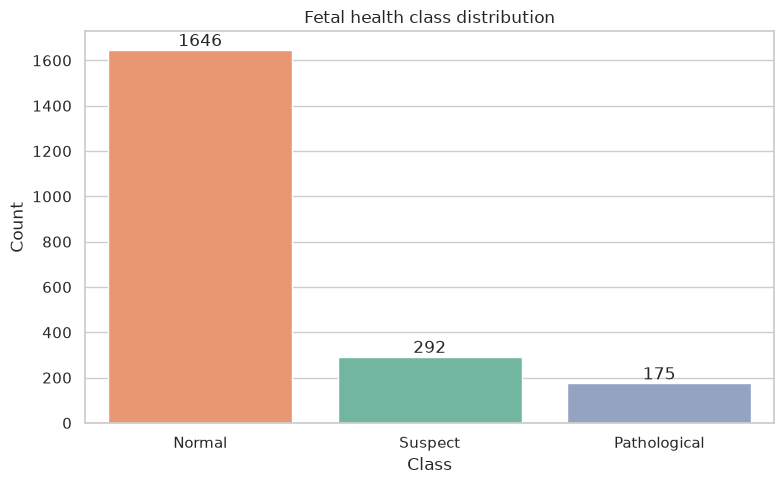

In [5]:
plot_df = df_clean.copy()
plot_df["class_name"] = plot_df[TARGET].map(CLASS_MAP)

fig, ax = plt.subplots()
order = ["Normal", "Suspect", "Pathological"]
sns.countplot(data=plot_df, x="class_name", order=order, hue="class_name", palette="Set2", legend=False, ax=ax)
ax.set_title("Fetal health class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Normal cases dominate. Suspect and Pathological are minority classes, so a high accuracy could hide poor recall on at-risk fetuses. Stratified sampling and macro-averaged metrics are needed later.

### 4.2 Feature distributions by class (boxplots)

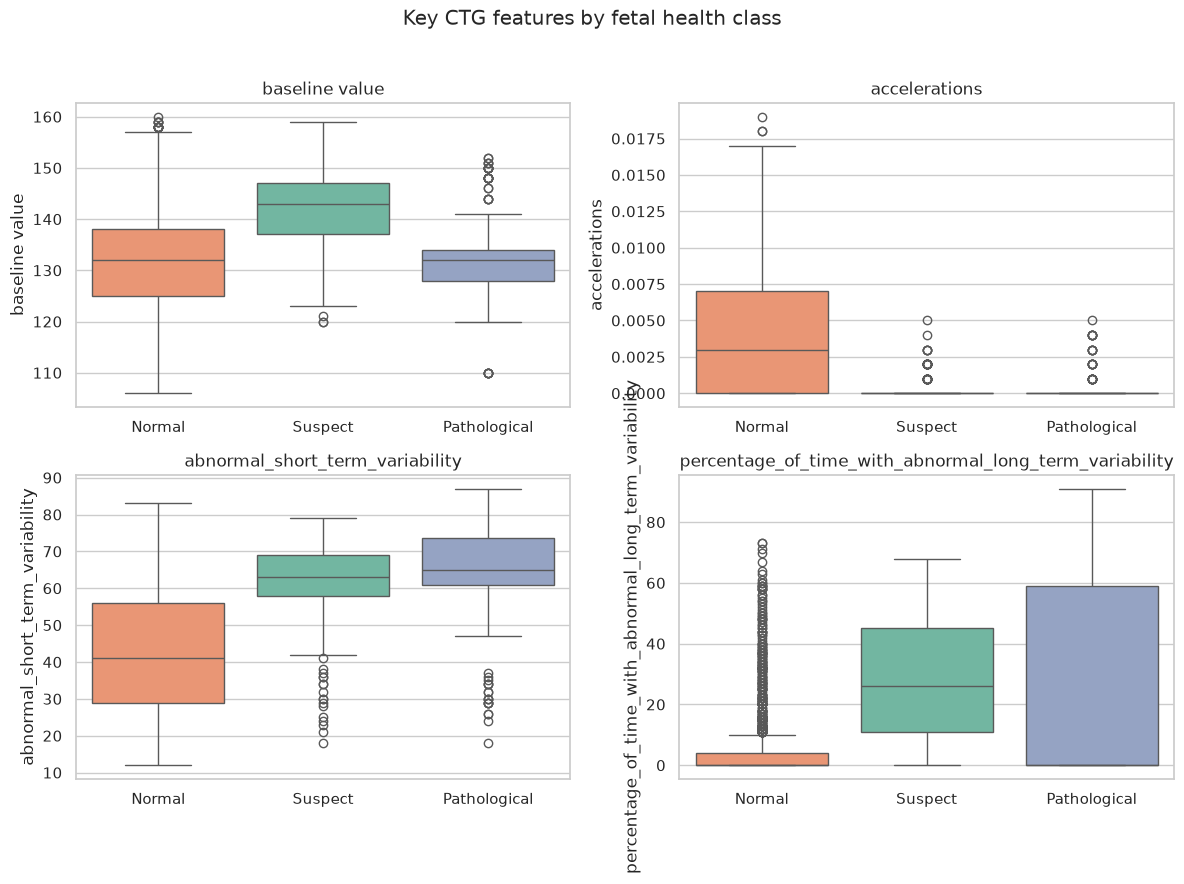

In [6]:
box_features = [
    "baseline value",
    "accelerations",
    "abnormal_short_term_variability",
    "percentage_of_time_with_abnormal_long_term_variability",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, box_features):
    sns.boxplot(data=plot_df, x="class_name", y=col, order=order, hue="class_name", palette="Set2", legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Key CTG features by fetal health class", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_boxplots_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Pathological / Suspect cases tend to show different variability and acceleration patterns than Normal. These separations motivate keeping clinical CTG features (and carefully treating outliers rather than deleting rare pathological extremes).

### 4.3 Correlation heatmap

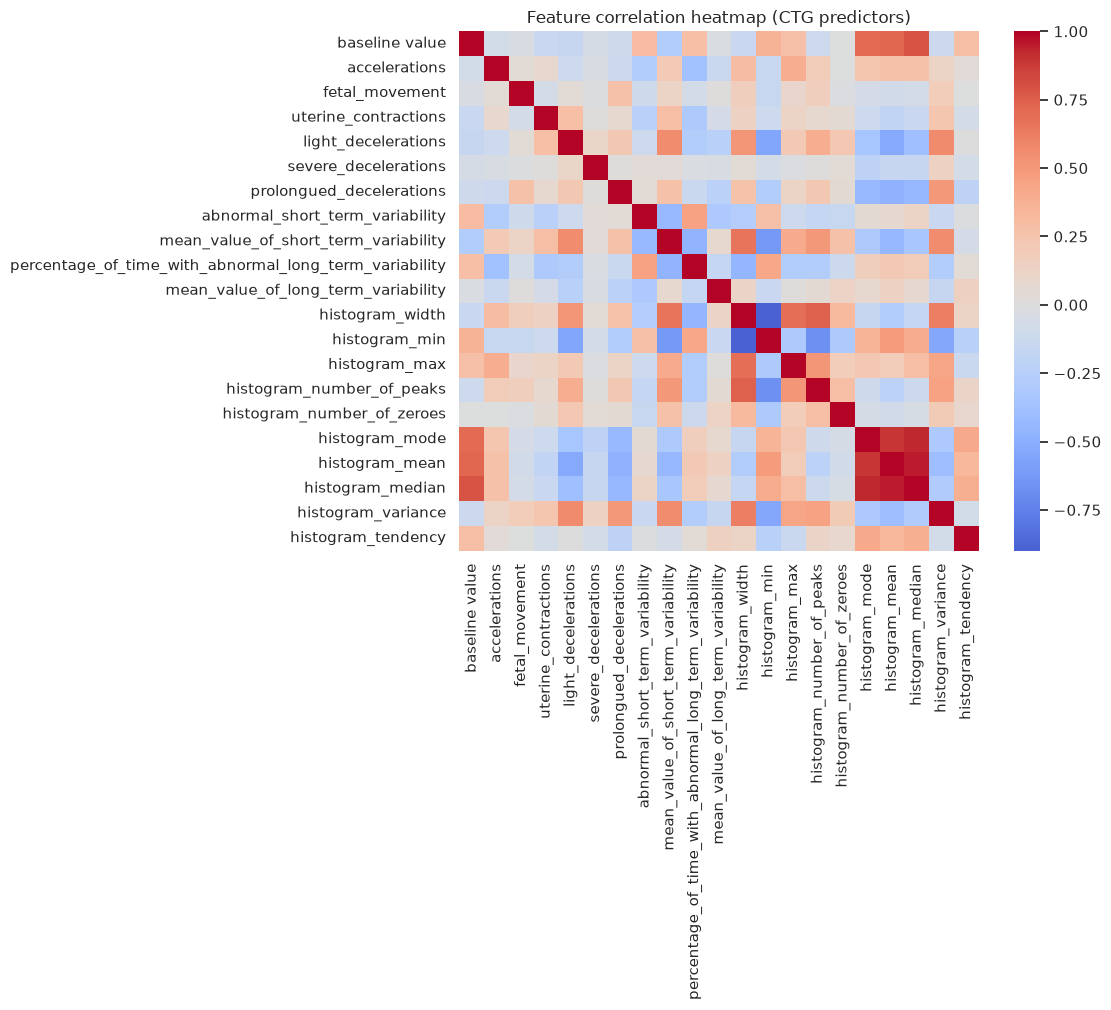

Top 10 |correlation| pairs:


histogram_mean   histogram_median             0.948077
histogram_mode   histogram_median             0.933166
histogram_width  histogram_min                0.899054
histogram_mode   histogram_mean               0.893083
baseline value   histogram_median             0.788487
histogram_width  histogram_number_of_peaks    0.746894
baseline value   histogram_mean               0.722152
                 histogram_mode               0.708074
histogram_width  histogram_max                0.692645
histogram_min    histogram_number_of_peaks    0.670410
dtype: float64

In [7]:
corr = df_clean[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Feature correlation heatmap (CTG predictors)")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Highlight strongest absolute correlations (excluding self-pairs)
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
)
print("Top 10 |correlation| pairs:")
display(corr_pairs.head(10))

**Interpretation:** Histogram-derived features (mode/mean/median/width) are highly correlated. That multicollinearity supports **feature selection** and **PCA** later, so models are not overloaded with redundant information.

## 5. Outlier handling (IQR winsorization)

**What:** Detect outliers with the IQR rule and **cap** (winsorize) extreme values.  
**Why:** Deleting outliers would risk removing rare Pathological CTG patterns. Capping reduces extreme influence while preserving class coverage.

In [8]:
df_out = df_clean.copy()
outlier_report = []

# Skip ordinal-like tendency; treat continuous CTG measures
outlier_cols = [c for c in feature_cols if c != "histogram_tendency"]

for col in outlier_cols:
    q1 = df_out[col].quantile(0.25)
    q3 = df_out[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df_out[col] < lower) | (df_out[col] > upper)
    n_out = int(mask.sum())
    outlier_report.append({"feature": col, "n_outliers": n_out, "lower": lower, "upper": upper})
    df_out[col] = df_out[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_report).sort_values("n_outliers", ascending=False)
display(outlier_df.head(10))
print("Total outlier flags across features:", int(outlier_df["n_outliers"].sum()))
print("Rows retained after winsorization:", len(df_out), "(no rows deleted)")

,feature,n_outliers,lower,upper
15,histogram_number_of_zeroes,502,0.0000,0.0000
2,fetal_movement,305,-0.0045,0.0075
9,percentage_of_time_with_abnormal_long_term_var...,305,-16.5000,27.5000
19,histogram_variance,184,-31.0000,57.0000
6,prolongued_decelerations,178,0.0000,0.0000
4,light_decelerations,150,-0.0045,0.0075
16,histogram_mode,73,100.5000,176.5000
10,mean_value_of_long_term_variability,71,-4.7000,20.1000
8,mean_value_of_short_term_variability,70,-0.8000,3.2000
17,histogram_mean,45,95.0000,175.0000


Total outlier flags across features: 1976
Rows retained after winsorization: 2113 (no rows deleted)


**Interpretation:** Several CTG features contain IQR outliers. Winsorization caps extremes instead of dropping rows, which is safer for an imbalanced medical screening dataset.

## 6. Encoding categorical / ordinal variables

**What:** Encode `histogram_tendency` (ordinal: -1, 0, 1) and create an explicit integer label for `fetal_health`.  
**Why:** Progress Review I requires encoding. CTG predictors are mostly already numeric; tendency and the target still need clear encoding for modelling libraries.

In [9]:
df_enc = df_out.copy()

# Ordinal encoding for histogram_tendency: keep natural order (-1 < 0 < 1)
tendency_order = {-1.0: 0, 0.0: 1, 1.0: 2}
df_enc["histogram_tendency_ord"] = df_enc["histogram_tendency"].map(tendency_order).astype(int)

# Label-encode target to integers 0/1/2 for sklearn consistency (maps from 1/2/3)
label_encoder = LabelEncoder()
df_enc["fetal_health_encoded"] = label_encoder.fit_transform(df_enc[TARGET].astype(int))

print("histogram_tendency value counts:")
display(df_enc["histogram_tendency"].value_counts().sort_index())
print("Encoded tendency mapping (-1,0,1) ->", tendency_order)
display(df_enc[["histogram_tendency", "histogram_tendency_ord"]].drop_duplicates().sort_values("histogram_tendency"))

print("\nTarget classes:", list(label_encoder.classes_))
print("Encoded target mapping:")
for cls, enc in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"  {cls} ({CLASS_MAP.get(float(cls), cls)}) -> {enc}")

display(df_enc[[TARGET, "fetal_health_encoded", "histogram_tendency", "histogram_tendency_ord"]].head())

histogram_tendency value counts:


histogram_tendency
-1.0     165
 0.0    1110
 1.0     838
Name: count, dtype: int64

Encoded tendency mapping (-1,0,1) -> {-1.0: 0, 0.0: 1, 1.0: 2}


,histogram_tendency,histogram_tendency_ord
22,-1.0,0
1,0.0,1
0,1.0,2



Target classes: [np.int64(1), np.int64(2), np.int64(3)]
Encoded target mapping:
  1 (Normal) -> 0
  2 (Suspect) -> 1
  3 (Pathological) -> 2


,fetal_health,fetal_health_encoded,histogram_tendency,histogram_tendency_ord
0,2.0,1,1.0,2
1,1.0,0,0.0,1
2,1.0,0,0.0,1
3,1.0,0,1.0,2
4,1.0,0,1.0,2


**Interpretation:** Ordinal encoding preserves tendency order. Label encoding maps fetal health to 0/1/2 without implying a regression scale beyond class IDs used by classifiers.

## 7. Normalization / scaling

**What:** Standardize continuous CTG features with `StandardScaler` (zero mean, unit variance).  
**Why:** Features use different units (rates, percentages, histogram counts). Scaling is required before PCA and distance/linear models.

In [10]:
scale_cols = [c for c in feature_cols if c != "histogram_tendency"] + ["histogram_tendency_ord"]

scaler = StandardScaler()
scaled = scaler.fit_transform(df_enc[scale_cols])
df_scaled = pd.DataFrame(scaled, columns=[f"{c}__scaled" for c in scale_cols], index=df_enc.index)

print("Scaled feature means (should be ~0):")
display(df_scaled.mean().round(6).head())
print("Scaled feature stds (should be ~1):")
display(df_scaled.std(ddof=0).round(6).head())

# Preview a couple of raw vs scaled columns
preview = pd.concat(
    [
        df_enc[["baseline value", "accelerations"]].reset_index(drop=True),
        df_scaled[["baseline value__scaled", "accelerations__scaled"]].reset_index(drop=True),
    ],
    axis=1,
)
display(preview.head())

Scaled feature means (should be ~0):


baseline value__scaled         -0.0
accelerations__scaled           0.0
fetal_movement__scaled          0.0
uterine_contractions__scaled   -0.0
light_decelerations__scaled     0.0
dtype: float64

Scaled feature stds (should be ~1):


baseline value__scaled          1.0
accelerations__scaled           1.0
fetal_movement__scaled          1.0
uterine_contractions__scaled    1.0
light_decelerations__scaled     1.0
dtype: float64

,baseline value,accelerations,baseline value__scaled,accelerations__scaled
0,120.0,0.000,-1.352782,-0.829250
1,132.0,0.006,-0.132665,0.737083
2,133.0,0.003,-0.030989,-0.046083
3,134.0,0.003,0.070687,-0.046083
4,132.0,0.007,-0.132665,0.998139


**Interpretation:** After scaling, features are comparable. Note: for the final leakage-safe workflow (Section 10), the scaler is re-fit on the **training split only**.

## 8. Feature engineering, selection, and dimension reduction

**What:** Create domain-inspired CTG ratios, select top features with ANOVA F-test (`SelectKBest`), and compress correlated information with PCA.  
**Why:** EDA showed imbalance-relevant clinical signals and strong histogram multicollinearity.

,count,mean,std,min,25%,50%,75%,max
total_decelerations,2113.0,0.001744,0.002529,0.000000,0.000000,0.000000,0.003000,7.500000e-03
accel_to_decel_ratio,2113.0,1850.576085,3467.295772,0.000000,0.000000,0.799840,2000.000000,1.500000e+04
short_long_variability_ratio,2113.0,143161.718783,571515.909437,0.027397,0.078014,0.128866,0.270588,3.200000e+06
abnormal_variability_sum,2113.0,53.624941,23.704941,12.000000,34.000000,53.000000,67.000000,1.145000e+02


SelectKBest kept k=12 features:


/home/neon-cultivator/us2/project-aiml/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [ 5  6 15] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/neon-cultivator/us2/project-aiml/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,feature,f_score
24,abnormal_variability_sum,489.092907
9,percentage_of_time_with_abnormal_long_term_var...,389.515915
7,abnormal_short_term_variability,337.703020
17,histogram_mean,272.144556
23,short_long_variability_ratio,254.308478
18,histogram_median,236.602507
16,histogram_mode,214.004785
1,accelerations,197.504226
8,mean_value_of_short_term_variability,154.378023
0,baseline value,137.833999


PCA components for 95% variance: 12
Explained variance ratio (first 5): [0.3171 0.1723 0.1194 0.0806 0.0723]
Cumulative variance: 0.9534


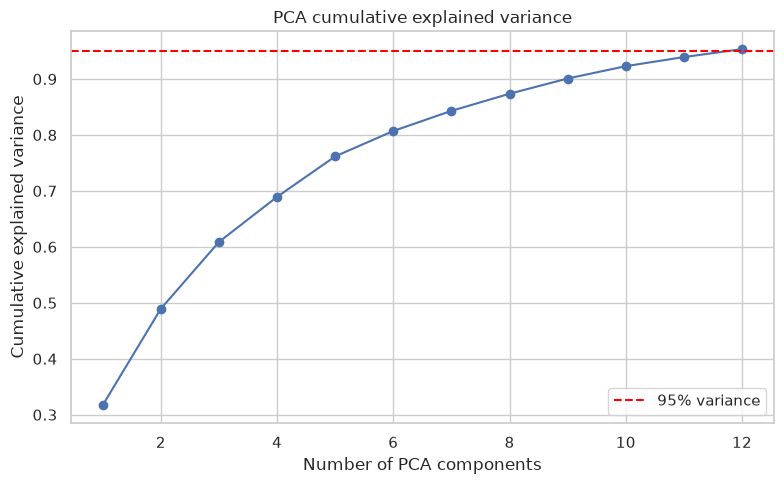

In [11]:
df_fe = df_enc.copy()

# Engineered features (small epsilon avoids divide-by-zero)
eps = 1e-6
df_fe["total_decelerations"] = (
    df_fe["light_decelerations"]
    + df_fe["severe_decelerations"]
    + df_fe["prolongued_decelerations"]
)
df_fe["accel_to_decel_ratio"] = df_fe["accelerations"] / (df_fe["total_decelerations"] + eps)
df_fe["short_long_variability_ratio"] = df_fe["mean_value_of_short_term_variability"] / (
    df_fe["mean_value_of_long_term_variability"] + eps
)
df_fe["abnormal_variability_sum"] = (
    df_fe["abnormal_short_term_variability"]
    + df_fe["percentage_of_time_with_abnormal_long_term_variability"]
)

engineered = [
    "total_decelerations",
    "accel_to_decel_ratio",
    "short_long_variability_ratio",
    "abnormal_variability_sum",
]
display(df_fe[engineered].describe().T)

X_fe_cols = scale_cols + engineered
X_all = df_fe[X_fe_cols].copy()
y_all = df_fe["fetal_health_encoded"].copy()

# Scale engineered + original (for selection / PCA demo on full cleaned set)
scaler_fe = StandardScaler()
X_scaled_fe = pd.DataFrame(
    scaler_fe.fit_transform(X_all),
    columns=X_fe_cols,
    index=X_all.index,
)

k = 12
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X_scaled_fe, y_all)
selected_features = list(np.array(X_fe_cols)[selector.get_support()])
scores = pd.DataFrame({"feature": X_fe_cols, "f_score": selector.scores_}).sort_values("f_score", ascending=False)

print(f"SelectKBest kept k={k} features:")
display(scores.head(k))

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled_fe)
print("PCA components for 95% variance:", pca.n_components_)
print("Explained variance ratio (first 5):", np.round(pca.explained_variance_ratio_[:5], 4))
print("Cumulative variance:", round(pca.explained_variance_ratio_.sum(), 4))

fig, ax = plt.subplots()
cum = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, len(cum) + 1), cum, marker="o")
ax.axhline(0.95, color="red", linestyle="--", label="95% variance")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA cumulative explained variance")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "04_pca_cumulative_variance.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Engineered deceleration/variability ratios add clinical signal. `SelectKBest` ranks discriminative CTG features; PCA shows correlated histogram information can be compressed into fewer components while keeping most variance.

## 9. Export processed dataset

In [12]:
processed = df_fe[X_fe_cols + [TARGET, "fetal_health_encoded"]].copy()
out_path = OUT_DIR / "fetal_health_processed.csv"
processed.to_csv(out_path, index=False)
print("Saved:", out_path)
print("Processed shape:", processed.shape)
display(processed.head())

Saved: /home/neon-cultivator/us2/project-aiml/results/outputs/fetal_health_processed.csv
Processed shape: (2113, 27)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_mean,histogram_median,histogram_variance,histogram_tendency_ord,total_decelerations,accel_to_decel_ratio,short_long_variability_ratio,abnormal_variability_sum,fetal_health,fetal_health_encoded
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,27.5,...,137.0,121.0,57.0,2,0.000,0.000000,0.208333,100.5,2.0,1
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,136.0,140.0,12.0,1,0.003,1.999334,0.201923,17.0,1.0,0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,135.0,138.0,13.0,1,0.003,0.999667,0.156716,16.0,1.0,0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,134.0,137.0,13.0,2,0.003,0.999667,0.119403,16.0,1.0,0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,136.0,138.0,11.0,2,0.000,7000.000000,0.120603,16.0,1.0,0


## 10. Bridge beyond Progress I — leakage-safe split + baseline model

This section is intentionally light preparation for Progress Review II:
- stratified train/test split
- imputer + scaler fitted on **train only**
- baseline Logistic Regression with accuracy and macro-F1

### Planned Progress II models
- **Random Forest** (handles non-linear CTG interactions; class_weight options)
- **SVM (RBF)** or second linear model with GridSearchCV
- Metrics: per-class Precision/Recall/F1, confusion matrix, stratified k-fold (macro-F1 primary under imbalance)

Train size: (1690, 25) Test size: (423, 25)
Train class mix:
 fetal_health_encoded
0    0.779
1    0.138
2    0.083
Name: proportion, dtype: float64
Test class mix:
 fetal_health_encoded
0    0.780
1    0.137
2    0.083
Name: proportion, dtype: float64

Baseline Logistic Regression — Accuracy: 0.8558 | Macro-F1: 0.7631

Classification report:
              precision    recall  f1-score   support

      Normal       0.96      0.88      0.92       330
     Suspect       0.54      0.74      0.62        58
Pathological       0.70      0.80      0.75        35

    accuracy                           0.86       423
   macro avg       0.73      0.81      0.76       423
weighted avg       0.88      0.86      0.86       423



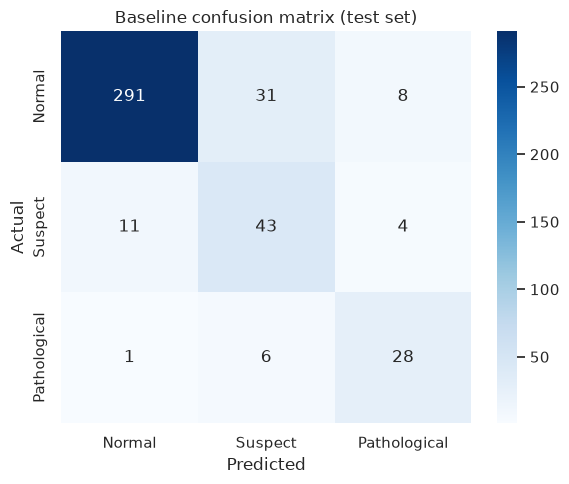

In [13]:
X = df_fe[X_fe_cols].copy()
y = df_fe["fetal_health_encoded"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train class mix:\n", y_train.value_counts(normalize=True).sort_index().round(3))
print("Test class mix:\n", y_test.value_counts(normalize=True).sort_index().round(3))

# Fit preprocessing on TRAIN only (avoids leakage)
pipe_imputer = SimpleImputer(strategy="median")
pipe_scaler = StandardScaler()

X_train_i = pipe_imputer.fit_transform(X_train)
X_test_i = pipe_imputer.transform(X_test)

X_train_s = pipe_scaler.fit_transform(X_train_i)
X_test_s = pipe_scaler.transform(X_test_i)

baseline = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
baseline.fit(X_train_s, y_train)
y_pred = baseline.predict(X_test_s)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"\nBaseline Logistic Regression — Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=[CLASS_MAP[float(c)] for c in label_encoder.classes_]))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[CLASS_MAP[float(c)] for c in label_encoder.classes_],
    yticklabels=[CLASS_MAP[float(c)] for c in label_encoder.classes_],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Baseline confusion matrix (test set)")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_baseline_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The baseline confirms the pipeline runs end-to-end without leakage. Macro-F1 is more informative than accuracy under class imbalance. Progress II will add a second algorithm, hyperparameter search, and cross-validation.